In [1]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
#from tpot.builtins import StackingEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.ensemble import GradientBoostingClassifier
df1 = pd.read_csv('balanced_group_stratified_fold_0.csv')
df2 = pd.read_csv('balanced_group_stratified_fold_1.csv')
df3 = pd.read_csv('balanced_group_stratified_fold_2.csv')
df4 = pd.read_csv('balanced_group_stratified_fold_3.csv')
df5 = pd.read_csv('balanced_group_stratified_fold_4.csv')

In [16]:
X_full = pd.read_pickle("/home/ubuntu/full_dataset.pkl")

In [2]:
all_dfs = [df1, df2, df3, df4, df5]  # or load from a list
combined_df = pd.concat(all_dfs, ignore_index=True)

In [3]:
combined_df.shape

(651696, 26)

In [4]:
# 2. Drop duplicates if necessary
combined_df = combined_df.drop_duplicates()

In [5]:
combined_df = combined_df.drop(columns=['Test'])

In [6]:
combined_df

,Gene_B,complex_id_B,Gene_A,complex_id_A,global_index,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_Cosine_Similarity,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,...,GF-12L95M_HUMANemb_Cosine_Similarity,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,Gene_1,Gene_2,pair_id,pairwise_label,Same_Complex,group_id
0,MRPL20,CPX-5226,MRPS30,CPX-5226,170548297,0.055306,-0.049358,0.058200,-0.009567,0.014625,...,0.784110,0.810524,0.769859,0.350919,MRPL20,MRPS30,MRPL20_MRPS30,1,1,12
1,SGCD,CPX-2424,SGCB,CPX-2454,167189667,0.102524,0.103210,0.038960,0.021262,0.010275,...,0.683949,0.752542,0.745347,0.271149,SGCB,SGCD,SGCB_SGCD,0,1,148
2,UBA52,CPX-7665,RPL41,CPX-5183,162534628,0.303719,0.218867,0.328298,0.314337,0.277950,...,0.327514,0.336932,0.328170,0.100595,RPL41,UBA52,RPL41_UBA52,0,1,37
3,RPS5,CPX-5223,RPS23,CPX-5223,168689581,0.350182,0.367019,0.375344,0.169027,0.355274,...,0.347273,0.359518,0.258161,-0.177412,RPS23,RPS5,RPS23_RPS5,1,1,226
4,RPL28,CPX-7664,RPL18,CPX-7664,161988725,0.379828,0.521894,0.561702,0.341592,0.433050,...,0.337194,0.381279,0.266353,0.390724,RPL18,RPL28,RPL18_RPL28,1,1,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651691,GID4,CPX-7901,LRRC59,NaN,73491352,0.058076,0.103925,0.168920,-0.006816,0.029619,...,0.806674,0.864956,0.850807,0.290961,GID4,LRRC59,GID4_LRRC59,0,0,144
651692,ZGLP1,NaN,PIGY,CPX-6502,102892472,-0.087258,-0.067971,0.159982,-0.062981,-0.062357,...,0.749625,0.751085,0.711430,0.445760,PIGY,ZGLP1,PIGY_ZGLP1,0,0,390
651693,PPP1R12C,NaN,NCOA2,CPX-816,13506443,0.160041,0.016289,-0.046582,-0.068155,-0.058433,...,0.741463,0.828842,0.800971,0.286153,NCOA2,PPP1R12C,NCOA2_PPP1R12C,0,0,148
651694,MAPKAPK5,NaN,SNRPB,CPX-26467,116784298,-0.013332,0.022776,0.028492,-0.094243,-0.051776,...,0.730336,0.739071,0.747962,0.426305,MAPKAPK5,SNRPB,MAPKAPK5_SNRPB,0,0,267


In [7]:
# 3. Re-split by group while preserving class balance
# GroupShuffleSplit doesn't balance classes itself, so we implement a custom version
def balanced_group_split(df, group_col, label_col, test_size=0.2, random_state=42):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    groups = df[group_col]
    labels = df[label_col]
    
    # Use splitter to get train/test group indices
    for train_idx, test_idx in splitter.split(df, labels, groups):
        train_df = df.iloc[train_idx]
        test_df = df.iloc[test_idx]
        break

    # Optional: Rebalance classes in training and testing (downsample majority)
    def balance(df):
        df_pos = df[df[label_col] == 1]
        df_neg = df[df[label_col] == 0]
        n = min(len(df_pos), len(df_neg))
        return pd.concat([df_pos.sample(n, random_state=42), df_neg.sample(n, random_state=42)])

    train_df_balanced = balance(train_df)
    test_df_balanced = balance(test_df)

    # Add 'Test' column
    df['Test'] = False
    df.loc[test_df_balanced.index, 'Test'] = True
    return df

In [8]:
# 4. Apply the function to get new train/test assignment
final_df = balanced_group_split(combined_df, group_col='group_id', label_col='Same_Complex')


In [9]:
final_df

,Gene_B,complex_id_B,Gene_A,complex_id_A,global_index,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_Cosine_Similarity,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,Gene_1,Gene_2,pair_id,pairwise_label,Same_Complex,group_id,Test
0,MRPL20,CPX-5226,MRPS30,CPX-5226,170548297,0.055306,-0.049358,0.058200,-0.009567,0.014625,...,0.810524,0.769859,0.350919,MRPL20,MRPS30,MRPL20_MRPS30,1,1,12,False
1,SGCD,CPX-2424,SGCB,CPX-2454,167189667,0.102524,0.103210,0.038960,0.021262,0.010275,...,0.752542,0.745347,0.271149,SGCB,SGCD,SGCB_SGCD,0,1,148,True
2,UBA52,CPX-7665,RPL41,CPX-5183,162534628,0.303719,0.218867,0.328298,0.314337,0.277950,...,0.336932,0.328170,0.100595,RPL41,UBA52,RPL41_UBA52,0,1,37,False
3,RPS5,CPX-5223,RPS23,CPX-5223,168689581,0.350182,0.367019,0.375344,0.169027,0.355274,...,0.359518,0.258161,-0.177412,RPS23,RPS5,RPS23_RPS5,1,1,226,False
4,RPL28,CPX-7664,RPL18,CPX-7664,161988725,0.379828,0.521894,0.561702,0.341592,0.433050,...,0.381279,0.266353,0.390724,RPL18,RPL28,RPL18_RPL28,1,1,37,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651691,GID4,CPX-7901,LRRC59,NaN,73491352,0.058076,0.103925,0.168920,-0.006816,0.029619,...,0.864956,0.850807,0.290961,GID4,LRRC59,GID4_LRRC59,0,0,144,False
651692,ZGLP1,NaN,PIGY,CPX-6502,102892472,-0.087258,-0.067971,0.159982,-0.062981,-0.062357,...,0.751085,0.711430,0.445760,PIGY,ZGLP1,PIGY_ZGLP1,0,0,390,False
651693,PPP1R12C,NaN,NCOA2,CPX-816,13506443,0.160041,0.016289,-0.046582,-0.068155,-0.058433,...,0.828842,0.800971,0.286153,NCOA2,PPP1R12C,NCOA2_PPP1R12C,0,0,148,False
651694,MAPKAPK5,NaN,SNRPB,CPX-26467,116784298,-0.013332,0.022776,0.028492,-0.094243,-0.051776,...,0.739071,0.747962,0.426305,MAPKAPK5,SNRPB,MAPKAPK5_SNRPB,0,0,267,False


In [10]:
# final_df.to_csv('final_train_test_df.csv', index=False)

In [11]:
final_df

,Gene_B,complex_id_B,Gene_A,complex_id_A,global_index,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_Cosine_Similarity,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,Gene_1,Gene_2,pair_id,pairwise_label,Same_Complex,group_id,Test
0,MRPL20,CPX-5226,MRPS30,CPX-5226,170548297,0.055306,-0.049358,0.058200,-0.009567,0.014625,...,0.810524,0.769859,0.350919,MRPL20,MRPS30,MRPL20_MRPS30,1,1,12,False
1,SGCD,CPX-2424,SGCB,CPX-2454,167189667,0.102524,0.103210,0.038960,0.021262,0.010275,...,0.752542,0.745347,0.271149,SGCB,SGCD,SGCB_SGCD,0,1,148,True
2,UBA52,CPX-7665,RPL41,CPX-5183,162534628,0.303719,0.218867,0.328298,0.314337,0.277950,...,0.336932,0.328170,0.100595,RPL41,UBA52,RPL41_UBA52,0,1,37,False
3,RPS5,CPX-5223,RPS23,CPX-5223,168689581,0.350182,0.367019,0.375344,0.169027,0.355274,...,0.359518,0.258161,-0.177412,RPS23,RPS5,RPS23_RPS5,1,1,226,False
4,RPL28,CPX-7664,RPL18,CPX-7664,161988725,0.379828,0.521894,0.561702,0.341592,0.433050,...,0.381279,0.266353,0.390724,RPL18,RPL28,RPL18_RPL28,1,1,37,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
651691,GID4,CPX-7901,LRRC59,NaN,73491352,0.058076,0.103925,0.168920,-0.006816,0.029619,...,0.864956,0.850807,0.290961,GID4,LRRC59,GID4_LRRC59,0,0,144,False
651692,ZGLP1,NaN,PIGY,CPX-6502,102892472,-0.087258,-0.067971,0.159982,-0.062981,-0.062357,...,0.751085,0.711430,0.445760,PIGY,ZGLP1,PIGY_ZGLP1,0,0,390,False
651693,PPP1R12C,NaN,NCOA2,CPX-816,13506443,0.160041,0.016289,-0.046582,-0.068155,-0.058433,...,0.828842,0.800971,0.286153,NCOA2,PPP1R12C,NCOA2_PPP1R12C,0,0,148,False
651694,MAPKAPK5,NaN,SNRPB,CPX-26467,116784298,-0.013332,0.022776,0.028492,-0.094243,-0.051776,...,0.739071,0.747962,0.426305,MAPKAPK5,SNRPB,MAPKAPK5_SNRPB,0,0,267,False


In [12]:
def add_reversed_pairs(df, gene1_col="Gene_1", gene2_col="Gene_2", pair_col="pair_id", drop_duplicates=False):
    """
    Given a dataframe with Gene_1, Gene_2, and pair_id columns, 
    returns a new dataframe with reversed pairs added.
    
    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    gene1_col : str
        Column name for the first gene.
    gene2_col : str
        Column name for the second gene.
    pair_col : str
        Column name for the pair identifier.
    drop_duplicates : bool
        If True, removes duplicate rows (useful if reversed pairs already exist).
    
    Returns
    -------
    pd.DataFrame
        Dataframe with original and reversed rows.
    """
    # Copy and swap columns
    df_rev = df.copy()
    df_rev[gene1_col], df_rev[gene2_col] = df[gene2_col], df[gene1_col]
    df_rev[pair_col] = df_rev[gene1_col] + "_" + df_rev[gene2_col]
    
    # Combine
    df_out = pd.concat([df, df_rev], ignore_index=True)
    
    # Optionally drop duplicates
    if drop_duplicates:
        df_out = df_out.drop_duplicates(subset=[gene1_col, gene2_col, pair_col])
    
    return df_out

In [13]:
final_df_rev = add_reversed_pairs(final_df)

In [14]:
final_df_rev['GeneAB'] = final_df_rev['pair_id'].to_list()


In [17]:
fdf = X_full[['GeneAB', 'Correlation']].merge(final_df_rev, on = 'GeneAB')

In [18]:
fdf

,GeneAB,Correlation_x,Gene_B,complex_id_B,Gene_A,complex_id_A,global_index,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation_y,Gene_1,Gene_2,pair_id,pairwise_label,Same_Complex,group_id,Test
0,PYDC1_PDCD7,0.129590,PDCD7,NaN,PYDC1,NaN,949724,-0.002205,0.060987,0.029355,...,0.828492,0.827239,0.393331,PYDC1,PDCD7,PYDC1_PDCD7,0,0,157,False
1,PYDC1_MED12,0.111745,MED12,CPX-3232,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.863639,0.829005,0.307163,PYDC1,MED12,PYDC1_MED12,0,0,283,False
2,PYDC1_MED12,0.111745,MED12,CPX-3263,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.863639,0.829005,0.307163,PYDC1,MED12,PYDC1_MED12,0,0,213,False
3,PYDC1_MED12,0.111745,MED12,CPX-3232,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.863639,0.829005,0.307163,PYDC1,MED12,PYDC1_MED12,0,0,283,False
4,PYDC1_HAGH,0.114990,HAGH,NaN,PYDC1,NaN,962471,-0.001889,0.063299,0.081107,...,0.802131,0.712199,0.513932,PYDC1,HAGH,PYDC1_HAGH,0,0,207,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300978,SLC9C2_PREP,0.416986,SLC9C2,NaN,PREP,NaN,56919019,0.025064,0.097351,0.010430,...,0.859370,0.843514,0.334006,SLC9C2,PREP,SLC9C2_PREP,0,0,256,False
300979,MRPL18_MRPL32,0.432775,MRPL18,CPX-5226,MRPL32,CPX-5226,71406245,0.072482,0.194232,0.216402,...,0.822036,0.793764,0.112782,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False
300980,MRPL18_MRPL32,0.432775,MRPL32,CPX-5226,MRPL18,CPX-5226,200531403,0.072482,0.194232,0.216402,...,0.822036,0.793764,0.432775,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False
300981,MRPL18_MRPL32,0.432775,MRPL32,CPX-5226,MRPL18,CPX-5226,200531403,0.072482,0.194232,0.216402,...,0.822036,0.793764,0.432775,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False


In [20]:
#pw = pd.read_pickle('/home/ubuntu/allpairs_spearman_correlation.pkl')

In [19]:
#pw[pw['Gene_AB']=='MRPL18_MRPL32']

In [21]:
fdf.drop(columns=['Correlation_y'], inplace=True)

In [22]:
fdf.rename(columns={'Correlation_x':'Correlation'}, inplace=True)

In [23]:
final_df = fdf

In [24]:
# FEATURES = ['scGPT_bc_embeddings_Cosine_Similarity',
#        'scGPT_pancancer_embeddings_Cosine_Similarity',
#        'scGPT_lung_embeddings_Cosine_Similarity',
#        'scGPT_heart_embeddings_Cosine_Similarity',
#        'scGPT_brain_embeddings_Cosine_Similarity',
#        'scGPT_kidney_embeddings_Cosine_Similarity',
#        'scGPT_human_embeddings_Cosine_Similarity',
#        'GF-6L30M_HUMANemb_Cosine_Similarity',
#        'GF-20L95M_HUMANemb_Cosine_Similarity',
#        'GF-12L95M_HUMANemb_Cosine_Similarity',
#        'GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity',
#        'GF-12L30M_HUMANemb_Cosine_Similarity', 'Correlation']


LABEL = ['Same_Complex']


In [25]:
FEATURES = ['scGPT_bc_embeddings_Cosine_Similarity',
       'scGPT_pancancer_embeddings_Cosine_Similarity',
       'scGPT_lung_embeddings_Cosine_Similarity',
       'scGPT_heart_embeddings_Cosine_Similarity',
       'scGPT_brain_embeddings_Cosine_Similarity',
       'scGPT_kidney_embeddings_Cosine_Similarity',
       'scGPT_human_embeddings_Cosine_Similarity',
       'GF-6L30M_HUMANemb_Cosine_Similarity',
       'GF-20L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity',
       'GF-12L30M_HUMANemb_Cosine_Similarity', 'Correlation']

X = final_df[FEATURES]  # use your feature columns
y = final_df['Same_Complex']   # binary labels

X_train = X[~final_df['Test']]
y_train = y[~final_df['Test']]
X_test = X[final_df['Test']]
y_test = y[final_df['Test']]

In [26]:
#X_full = pd.read_pickle("/home/ubuntu/full_dataset.pkl")

In [27]:
X_full.columns

Index(['scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'GeneAB', 'Correlation',
       'Same_Complex'],
      dtype='object')

In [28]:
FEATURES_og = ['scGPT_bc_embeddings_Cosine_Similarity',
       'scGPT_pancancer_embeddings_Cosine_Similarity',
       'scGPT_lung_embeddings_Cosine_Similarity',
       'scGPT_heart_embeddings_Cosine_Similarity',
       'scGPT_brain_embeddings_Cosine_Similarity',
       'scGPT_kidney_embeddings_Cosine_Similarity',
       'scGPT_human_embeddings_Cosine_Similarity',
       'GF-6L30M_HUMANemb_Cosine_Similarity',
       'GF-20L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity',
       'GF-12L30M_HUMANemb_Cosine_Similarity', 'Correlation']

FEATURES = ['scGPT_bc_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-20L95M_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L30M_HUMANemb_similarities', 'Correlation']
mapper = dict(zip(FEATURES, FEATURES_og))
import pandas as pd
X_full = X_full[FEATURES].dropna()
X_full.rename(columns=mapper, inplace=True)

In [29]:
X_full

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,GF-12L95M_HUMANemb_Cosine_Similarity,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation
896178,0.063506,0.135321,0.125535,0.135128,0.383622,0.079211,0.235762,0.549340,0.188242,0.876189,0.879979,0.841622,0.201096
896179,-0.056565,0.079216,-0.021724,0.012198,0.222155,-0.051431,0.163293,0.393251,0.173845,0.779322,0.793168,0.762249,0.069745
896180,0.116124,0.308463,0.087753,0.112959,0.410780,0.055358,0.228007,0.585679,0.394791,0.899145,0.883349,0.825831,0.346303
896181,0.016978,0.058653,-0.049605,-0.008472,0.003432,-0.041763,-0.000696,0.347202,0.097802,0.738388,0.803293,0.789023,0.133561
896182,-0.031810,0.006320,-0.091508,-0.121315,-0.185753,-0.089556,-0.130848,0.347644,0.157392,0.742027,0.780049,0.778803,0.182313
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197988431,-0.034060,0.012347,0.033887,0.082821,-0.062600,0.051485,-0.041738,0.479248,0.155880,0.790348,0.825441,0.757885,0.134413
197988432,-0.029417,0.164719,0.013728,0.010290,-0.015519,-0.024196,0.027149,0.358243,0.215347,0.787139,0.840510,0.812317,0.371397
197988433,-0.001769,0.019778,-0.052413,0.021896,-0.043208,-0.018944,-0.002630,0.335464,0.053060,0.715039,0.769924,0.775723,0.236806
197988435,0.035068,-0.003189,0.005471,0.027976,0.008205,0.051279,0.016252,0.420288,0.153767,0.713602,0.809072,0.706953,0.437175


In [52]:
#pd.read_pickle("/home/ubuntu/gene_embedding_analysis/full_dataset.pkl").columns

In [53]:
#gene_ab = pd.read_pickle("/home/ubuntu/gene_embedding_analysis/full_dataset.pkl").dropna()[['GeneAB']].to_list()

In [30]:
from tpot.builtins import StackingEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.ensemble import GradientBoostingClassifier

In [36]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import Normalizer
import numpy as np

class ManualStackingSGD(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 rf_params=None,
                 sgd_params=None,
                 norm='l1'):
        self.rf_params = rf_params or {
            'bootstrap': True,
            'criterion': "entropy",
            'max_features': 0.45,
            'min_samples_leaf': 3,
            'min_samples_split': 2,
            'n_estimators': 100,
            'random_state': 42
        }
        self.sgd_params = sgd_params or {
            'alpha': 0.01,
            'eta0': 0.01,
            'fit_intercept': False,
            'l1_ratio': 0.75,
            'learning_rate': "constant",
            'loss': "squared_hinge",
            'penalty': "elasticnet",
            'power_t': 0.5,
            'random_state': 42
        }
        self.norm = norm

        self.rf = RandomForestClassifier(**self.rf_params)
        self.sgd = SGDClassifier(**self.sgd_params)
        self.normalizer = Normalizer(norm=self.norm)

    def fit(self, X, y):
        self.rf.fit(X, y)
        rf_scores = self.rf.predict_proba(X)[:, 1].reshape(-1, 1)
        X_stacked = np.hstack((X.values if hasattr(X, "values") else X, rf_scores))
        X_norm = self.normalizer.fit_transform(X_stacked)
        self.sgd.fit(X_norm, y)
        return self

    def predict(self, X):
        rf_scores = self.rf.predict_proba(X)[:, 1].reshape(-1, 1)
        X_stacked = np.hstack((X.values if hasattr(X, "values") else X, rf_scores))
        X_norm = self.normalizer.transform(X_stacked)
        return self.sgd.predict(X_norm)

    def decision_function(self, X):
        rf_scores = self.rf.predict_proba(X)[:, 1].reshape(-1, 1)
        X_stacked = np.hstack((X.values if hasattr(X, "values") else X, rf_scores))
        X_norm = self.normalizer.transform(X_stacked)
        return self.sgd.decision_function(X_norm)


exported_pipeline = make_pipeline(
    StackingEstimator(estimator=RandomForestClassifier(
        bootstrap=True, criterion="entropy", max_features=0.45,
        min_samples_leaf=3, min_samples_split=2, n_estimators=100
    )),
    Normalizer(norm="l1"),
    SGDClassifier(
        alpha=0.01, eta0=0.01, fit_intercept=False, l1_ratio=0.75,
        learning_rate="constant", loss="squared_hinge",
        penalty="elasticnet", power_t=0.5
    )
)

gb_exported_pipeline = GradientBoostingClassifier(learning_rate=0.5, max_depth=10, max_features=0.6000000000000001, min_samples_leaf=4, min_samples_split=19, n_estimators=100, subsample=0.8)

def get_model_outputs(model, X_train, y_train, X_full):

    print('fitting')
    model.fit(X_train, y_train)

    # X_test should be the whole dataset here
    
    print('Running predictions:')
    print('Outputs:')
    outputs = {
        'model': model,
        'predictions': model.predict(X_full)
    }

    print('Finished generating predictions')
    print(outputs)

    print('Predict probabilities starting')
    if hasattr(model, "predict_proba"):
        print('getting probabilities')
        outputs['probabilities'] = model.predict_proba(X_full)[:, 1]
    else:
        print('no probs available')
        outputs['probabilities'] = None

    if hasattr(model, "decision_function"):
        print('getting decision scores')
        outputs['decision_scores'] = model.decision_function(X_full)
    else:
        print('no decision scores available')
        outputs['decision_scores'] = None

    return outputs



# def get_model_outputs(model, X_train, y_train, X_full, batch_size=100000):
#     print('Fitting model')
#     model.fit(X_train, y_train)
#     print('Finished fitting model')
    
#     # Batch predictions to reduce memory usage
#     y_pred_full = []
#     y_proba_full = []

#     num_batches = (len(X_full) + batch_size - 1) // batch_size  # Ceiling division

#     print('Starting batch predictions')
#     for i in tqdm(range(0, len(X_full), batch_size), desc="Batch predicting", total=num_batches):
#         X_batch = X_full[i:i + batch_size]
#         preds = model.predict(X_batch)
#         probs = model.predict_proba(X_batch)[:, 1]
#         print("Default print:", probs[:5])
#         print("High precision print:", [f"{p:.10f}" for p in probs[:5]])
#         y_pred_full.append(preds)
#         y_proba_full.append(probs)
    
#     y_pred_full = np.concatenate(y_pred_full)
#     y_proba_full = np.concatenate(y_proba_full)
    
#     return {
#         "model": model,
#         "predictions": y_pred_full,
#         "probabilities": y_proba_full
#     }

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc
)
import numpy as np
from tqdm import tqdm  
from sklearn.metrics import average_precision_score
models = {
        "Logistic Regression": LogisticRegression(max_iter=10000),
        "SGD": SGDClassifier(loss='log_loss', max_iter=10000, random_state=42),
        "LinearSVC": LinearSVC(max_iter=10000, verbose=0, random_state=42),
        "TPOT Gradient Boosting": gb_exported_pipeline, 
        "TPOT Stacked RF SGD":  ManualStackingSGD()
    }


#         "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),

#models = {
#     "Random Forest_n10000": RandomForestClassifier(n_estimators=10000, n_jobs=-1)
# }

In [38]:
_all_model_results_ = {}

for name, model in tqdm(models.items(), desc="Fitting models"):
    print(name)
    try:
        result = get_model_outputs(model, X_train, y_train, X_full)
        _all_model_results_[name] = result
    except Exception as e:
        print(f"⚠️ Error with model '{name}': {e}")

print('DUMPING MODEL N=10000')
with open('all_model_results_not_rf_correct_correlation.pkl', 'wb') as f:
    pickle.dump(_all_model_results_, f)

Fitting models:   0%|          | 0/5 [00:00<?, ?it/s]

Logistic Regression
fitting
Running predictions:
Outputs:
Finished generating predictions
{'model': LogisticRegression(max_iter=10000), 'predictions': array([0, 0, 0, ..., 0, 0, 1])}
Predict probabilities starting
getting probabilities
getting decision scores


Fitting models:  20%|██        | 1/5 [00:07<00:31,  7.91s/it]

SGD
fitting
Running predictions:
Outputs:
Finished generating predictions
{'model': SGDClassifier(loss='log_loss', max_iter=10000, random_state=42), 'predictions': array([0, 0, 0, ..., 0, 0, 1])}
Predict probabilities starting
getting probabilities
getting decision scores


Fitting models:  40%|████      | 2/5 [00:15<00:23,  7.83s/it]

...

Fitting models:  80%|████████  | 4/5 [27:11<10:39, 639.96s/it]

TPOT Stacked RF SGD
fitting
Running predictions:
Outputs:
Finished generating predictions
{'model': ManualStackingSGD(rf_params={'bootstrap': True, 'criterion': 'entropy',
                             'max_features': 0.45, 'min_samples_leaf': 3,
                             'min_samples_split': 2, 'n_estimators': 100,
                             'random_state': 42},
                  sgd_params={'alpha': 0.01, 'eta0': 0.01,
                              'fit_intercept': False, 'l1_ratio': 0.75,
                              'learning_rate': 'constant',
                              'loss': 'squared_hinge', 'penalty': 'elasticnet',
                              'power_t': 0.5, 'random_state': 42}), 'predictions': array([0, 0, 0, ..., 0, 0, 0])}
Predict probabilities starting
no probs available
getting decision scores


Fitting models: 100%|██████████| 5/5 [1:19:40<00:00, 956.01s/it] 

DUMPING MODEL N=10000


NameError: name 'pickle' is not defined

In [65]:
len(all_model_results_10000['Random Forest_n10000']['probabilities'])

170976830

In [39]:
len(_all_model_results_["Logistic Regression"]['probabilities'])

170976830

In [69]:
# with open('/home/ubuntu/all_model_results_10000_correct_correlation.pkl', 'wb') as f:
#     pickle.dump(all_model_results_10000, f)

In [68]:
# import pickle
# with open('all_model_results_10000_correct_correlation.pkl', 'wb') as f:
#     pickle.dump(all_model_results_10000, f)

In [40]:
import pandas as pd
X_full = pd.read_pickle("/home/ubuntu/full_dataset.pkl")

In [41]:
X_full.columns

Index(['scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'GeneAB', 'Correlation',
       'Same_Complex'],
      dtype='object')

In [43]:
import pickle

with open('all_model_results_not_rf_correct_correlation.pkl', 'wb') as fo:
    pickle.dump(_all_model_results_, fo)
with open("all_model_results_10000_correct_correlation.pkl", "rb") as f:
    rf_dict = pickle.load(f)

In [44]:
rf_dict

{'Random Forest_n10000': {'model': RandomForestClassifier(n_estimators=10000, n_jobs=-1),
  'predictions': array([0, 0, 0, ..., 0, 0, 0]),
  'probabilities': array([0.0854, 0.0457, 0.0666, ..., 0.0383, 0.011 , 0.1937])}}

In [45]:
_all_model_results_

{'Logistic Regression': {'model': LogisticRegression(max_iter=10000),
  'predictions': array([0, 0, 0, ..., 0, 0, 1]),
  'probabilities': array([0.29027908, 0.21799046, 0.24257211, ..., 0.26191747, 0.12100986,
         0.74897681]),
  'decision_scores': array([-0.894029  , -1.27741562, -1.13862933, ..., -1.03602619,
         -1.98290167,  1.09316267])},
 'SGD': {'model': SGDClassifier(loss='log_loss', max_iter=10000, random_state=42),
  'predictions': array([0, 0, 0, ..., 0, 0, 1]),
  'probabilities': array([0.33704614, 0.21045014, 0.29159656, ..., 0.24132505, 0.13980805,
         0.64396532]),
  'decision_scores': array([-0.67648555, -1.3222142 , -0.88764256, ..., -1.14542866,
         -1.81688515,  0.59261673])},
 'LinearSVC': {'model': LinearSVC(max_iter=10000, random_state=42),
  'predictions': array([0, 0, 0, ..., 0, 0, 1]),
  'probabilities': None,
  'decision_scores': array([-0.31555288, -0.42923479, -0.40725331, ..., -0.34130634,
         -0.64952996,  0.36293214])},
 'TPOT Gra

In [78]:
for mod in list(all_model_results_10000.keys()):
    print(mod)

Random Forest_n10000


In [79]:
all_model_results_10000['Random Forest_n10000'].keys()

dict_keys(['model', 'predictions', 'probabilities'])

In [47]:
for mod in list(_all_model_results_.keys()):
    for p in ['predictions', 'probabilities', 'decision_scores']:
        col_name = f'{mod}_{p}'
        X_full[col_name] = _all_model_results_[mod][p]

In [48]:
for mod in list(rf_dict.keys()):
    for p in ['predictions', 'probabilities']:
        col_name = f'{mod}_{p}'
        X_full[col_name] = rf_dict[mod][p]

In [49]:
X_full.columns

Index(['scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'GeneAB', 'Correlation',
       'Same_Complex', 'Logistic Regression_predictions',
       'Logistic Regression_probabilities',
       'Logistic Regression_decision_scores', 'SGD_predictions',
       'SGD_probabilities', 'SGD_decision_scores', 'LinearSVC_predictions',
       'LinearSVC_probabilities', 'LinearSVC_decision_scores',
       'TPOT Gradient Boosting_predictions',
       'TPOT Gradient Boosting_probabilities',
  

In [ ]:
X_full['Random Forest_n10000_probabilities'].hist(bins=50)

In [50]:
def plot_roc_curves(results_dict, y_test):
    plt.figure(figsize=(10, 7))
    for name, result in results_dict.items():
        y_score = None
        if result['probabilities'] is not None:
            y_score = result['probabilities']
        elif result['decision_scores'] is not None:
            y_score = result['decision_scores']
        
        if y_score is not None:
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('full_train_test_roc.png',dpi=300)
    plt.show()

def plot_pr_curves(results_dict, y_test):
    plt.figure(figsize=(10, 7))
    for name, result in results_dict.items():
        y_score = None
        if result['probabilities'] is not None:
            y_score = result['probabilities']
        elif result['decision_scores'] is not None:
            y_score = result['decision_scores']
        
        if y_score is not None:
            precision, recall, _ = precision_recall_curve(y_test, y_score)
            ap = average_precision_score(y_test, y_score)
            plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig('full_train_test_auprc.png', dpi=300)
    plt.show()

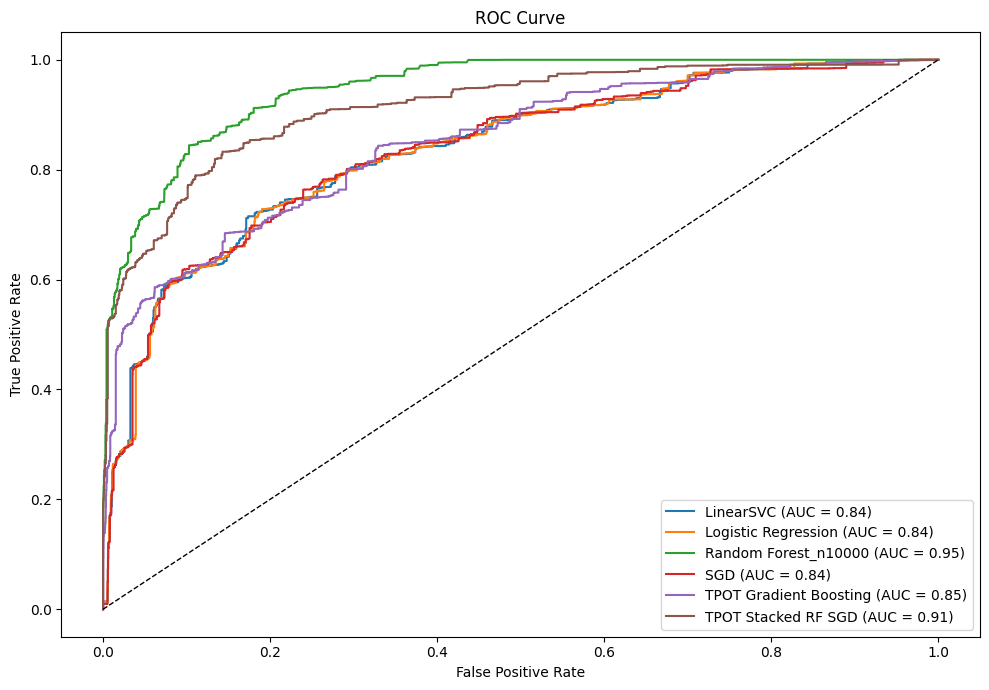

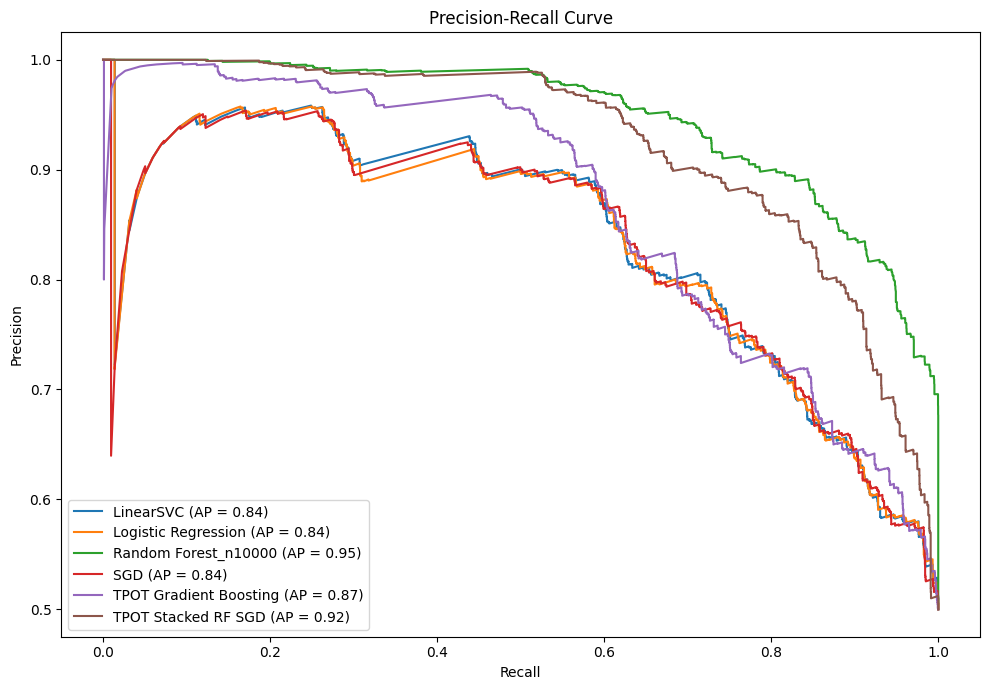

In [69]:
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def _get_model_prefixes(df):
    """Extract unique model prefixes from DataFrame columns."""
    prefixes = set()
    for col in df.columns:
        match = re.match(r"(.+)(_probabilities|_decision_scores)$", col)
        if match:
            prefixes.add(match.group(1))
    return sorted(prefixes)


def plot_roc_curves(df, y_test_col):
    """
    Plot ROC curves for all models in a DataFrame.
    Automatically detects models by suffixes '_probabilities' and '_decision_scores'.
    """
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        # Prefer probabilities if available, else fallback to decision scores
        if f"{prefix}_probabilities" in df.columns:
            y_score = df[f"{prefix}_probabilities"].values
        elif f"{prefix}_decision_scores" in df.columns:
            y_score = df[f"{prefix}_decision_scores"].values
        else:
            continue  # skip if neither exists

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{prefix} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("full_train_test_roc.png", dpi=300)
    plt.show()


def plot_pr_curves(df, y_test_col):
    """
    Plot Precision-Recall curves for all models in a DataFrame.
    Automatically detects models by suffixes '_probabilities' and '_decision_scores'.
    """
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        if f"{prefix}_probabilities" in df.columns:
            y_score = df[f"{prefix}_probabilities"].values
        elif f"{prefix}_decision_scores" in df.columns:
            y_score = df[f"{prefix}_decision_scores"].values
        else:
            continue

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        plt.plot(recall, precision, label=f"{prefix} (AP = {ap:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig("full_train_test_auprc.png", dpi=300)
    plt.show()

import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def _get_model_prefixes(df):
    """Extract unique model prefixes from DataFrame columns."""
    prefixes = set()
    for col in df.columns:
        match = re.match(r"(.+)(_probabilities|_decision_scores)$", col)
        if match:
            prefixes.add(match.group(1))
    return sorted(prefixes)


def _get_valid_scores(df, prefix):
    """Return a valid score array for a model prefix, or None if not usable."""
    colname = None
    if f"{prefix}_probabilities" in df.columns:
        colname = f"{prefix}_probabilities"
    elif f"{prefix}_decision_scores" in df.columns:
        colname = f"{prefix}_decision_scores"

    if colname is None:
        return None

    y_score = df[colname].values
    # Skip if entirely None or cannot be cast to float
    if all(v is None for v in y_score):
        return None
    try:
        y_score = np.array(y_score, dtype=float)
    except Exception:
        return None

    return y_score


def plot_roc_curves(df, y_test_col):
    """
    Plot ROC curves for all models in a DataFrame.
    Safely skips models with invalid or missing score columns.
    """
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        y_score = _get_valid_scores(df, prefix)
        if y_score is None:
            print(f"Skipping {prefix} (no valid scores)")
            continue

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{prefix} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("full_train_test_roc.png", dpi=300)
    plt.show()


def plot_pr_curves(df, y_test_col):
    """
    Plot Precision-Recall curves for all models in a DataFrame.
    Safely skips models with invalid or missing score columns.
    """
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        y_score = _get_valid_scores(df, prefix)
        if y_score is None:
            print(f"Skipping {prefix} (no valid scores)")
            continue

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        plt.plot(recall, precision, label=f"{prefix} (AP = {ap:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig("full_train_test_auprc.png", dpi=300)
    plt.show()

import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def _get_model_prefixes(df):
    """Extract unique model prefixes from DataFrame columns."""
    prefixes = set()
    for col in df.columns:
        match = re.match(r"(.+)(_probabilities|_decision_scores)$", col)
        if match:
            prefixes.add(match.group(1))
    return sorted(prefixes)


def _get_valid_scores(df, prefix):
    """
    Return a valid score array for a model prefix, preferring probabilities if valid,
    otherwise falling back to decision scores.
    """
    for suffix in ["_probabilities", "_decision_scores"]:
        colname = f"{prefix}{suffix}"
        if colname not in df.columns:
            continue

        y_score = df[colname].values
        # Skip if entirely None
        if all(v is None for v in y_score):
            continue
        try:
            y_score = np.array(y_score, dtype=float)
        except Exception:
            continue

        return y_score  # return the first valid option

    return None


def plot_roc_curves(df, y_test_col):
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        y_score = _get_valid_scores(df, prefix)
        if y_score is None:
            print(f"Skipping {prefix} (no valid scores)")
            continue

        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{prefix} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("full_train_test_roc.png", dpi=300)
    plt.show()


def plot_pr_curves(df, y_test_col):
    y_test = df[y_test_col].values
    model_prefixes = _get_model_prefixes(df)

    plt.figure(figsize=(10, 7))
    for prefix in model_prefixes:
        y_score = _get_valid_scores(df, prefix)
        if y_score is None:
            print(f"Skipping {prefix} (no valid scores)")
            continue

        precision, recall, _ = precision_recall_curve(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        plt.plot(recall, precision, label=f"{prefix} (AP = {ap:.2f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig("full_train_test_auprc.png", dpi=300)
    plt.show()


_get_model_prefixes(xf)
plot_roc_curves(xf, 'Same_Complex')
plot_pr_curves(xf, 'Same_Complex')

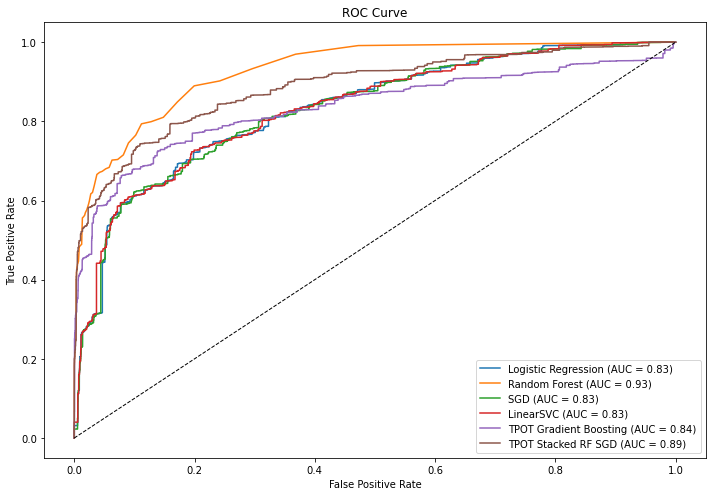

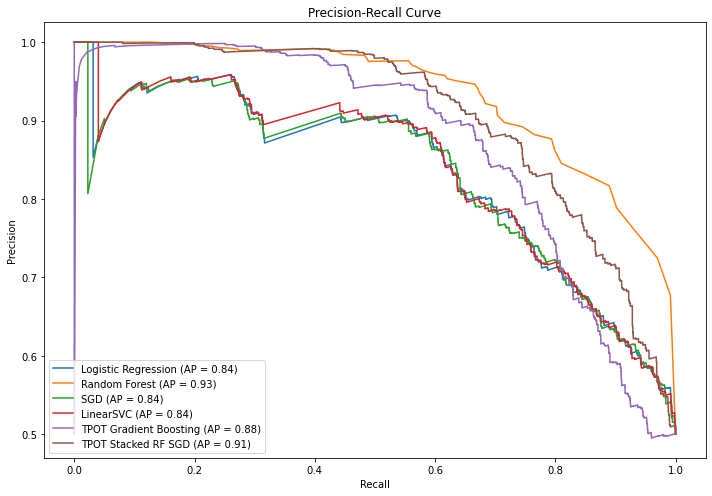

In [44]:
plot_roc_curves(all_model_results, y_test)
plot_pr_curves(all_model_results, y_test)

In [60]:
xf = final_df[final_df['Test']==True][['GeneAB']].merge(X_full, on = 'GeneAB')

In [64]:
xf.columns

Index(['GeneAB', 'scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'Correlation', 'Same_Complex',
       'Logistic Regression_predictions', 'Logistic Regression_probabilities',
       'Logistic Regression_decision_scores', 'SGD_predictions',
       'SGD_probabilities', 'SGD_decision_scores', 'LinearSVC_predictions',
       'LinearSVC_probabilities', 'LinearSVC_decision_scores',
       'TPOT Gradient Boosting_predictions',
       'TPOT Gradient Boosting_probabilities',
       'T

In [68]:
xf[['LinearSVC_probabilities', 'LinearSVC_decision_scores']]

,LinearSVC_probabilities,LinearSVC_decision_scores
0,None,-0.501197
1,None,-0.683453
2,None,-0.683453
3,None,-0.683453
4,None,-0.683453
...,...,...
14775,None,-1.061279
14776,None,-0.611547
14777,None,-0.492943
14778,None,-0.360097


In [56]:
f_ = final_df[['scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'Correlation', 'GeneAB',

,GeneAB,Correlation,Gene_B,complex_id_B,Gene_A,complex_id_A,global_index,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_Cosine_Similarity,...,GF-12L95M_HUMANemb_Cosine_Similarity,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Gene_1,Gene_2,pair_id,pairwise_label,Same_Complex,group_id,Test
0,PYDC1_PDCD7,0.129590,PDCD7,NaN,PYDC1,NaN,949724,-0.002205,0.060987,0.029355,...,0.818167,0.828492,0.827239,PYDC1,PDCD7,PYDC1_PDCD7,0,0,157,False
1,PYDC1_MED12,0.111745,MED12,CPX-3232,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.866317,0.863639,0.829005,PYDC1,MED12,PYDC1_MED12,0,0,283,False
2,PYDC1_MED12,0.111745,MED12,CPX-3263,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.866317,0.863639,0.829005,PYDC1,MED12,PYDC1_MED12,0,0,213,False
3,PYDC1_MED12,0.111745,MED12,CPX-3232,PYDC1,NaN,954649,0.162045,0.178061,0.144317,...,0.866317,0.863639,0.829005,PYDC1,MED12,PYDC1_MED12,0,0,283,False
4,PYDC1_HAGH,0.114990,HAGH,NaN,PYDC1,NaN,962471,-0.001889,0.063299,0.081107,...,0.767750,0.802131,0.712199,PYDC1,HAGH,PYDC1_HAGH,0,0,207,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300978,SLC9C2_PREP,0.416986,SLC9C2,NaN,PREP,NaN,56919019,0.025064,0.097351,0.010430,...,0.844921,0.859370,0.843514,SLC9C2,PREP,SLC9C2_PREP,0,0,256,False
300979,MRPL18_MRPL32,0.432775,MRPL18,CPX-5226,MRPL32,CPX-5226,71406245,0.072482,0.194232,0.216402,...,0.796915,0.822036,0.793764,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False
300980,MRPL18_MRPL32,0.432775,MRPL32,CPX-5226,MRPL18,CPX-5226,200531403,0.072482,0.194232,0.216402,...,0.796915,0.822036,0.793764,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False
300981,MRPL18_MRPL32,0.432775,MRPL32,CPX-5226,MRPL18,CPX-5226,200531403,0.072482,0.194232,0.216402,...,0.796915,0.822036,0.793764,MRPL18,MRPL32,MRPL18_MRPL32,1,1,12,False


In [55]:
plot = X_full[['GeneAB', 'Logistic Regression_predictions',
       'Logistic Regression_probabilities',
       'Logistic Regression_decision_scores', 'SGD_predictions',
       'SGD_probabilities', 'SGD_decision_scores', 'LinearSVC_predictions',
       'LinearSVC_probabilities', 'LinearSVC_decision_scores',
       'TPOT Gradient Boosting_predictions',
       'TPOT Gradient Boosting_probabilities',
       'TPOT Gradient Boosting_decision_scores',
       'TPOT Stacked RF SGD_predictions', 'TPOT Stacked RF SGD_probabilities',
       'TPOT Stacked RF SGD_decision_scores',
       'Random Forest_n10000_predictions',
       'Random Forest_n10000_probabilities']].merge(

Index(['scGPT_heart_embeddings_similarities',
       'scGPT_brain_embeddings_similarities',
       'scGPT_human_embeddings_similarities',
       'scGPT_bc_embeddings_similarities', 'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_similarities',
       'scGPT_kidney_embeddings_similarities',
       'scGPT_pancancer_embeddings_similarities',
       'GF-20L95M_HUMANemb_similarities', 'GF-12L30M_HUMANemb_similarities',
       'GF-6L30M_HUMANemb_similarities',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_similarities',
       'GF-12L95M_HUMANemb_similarities', 'GeneAB', 'Correlation',
       'Same_Complex', 'Logistic Regression_predictions',
       'Logistic Regression_probabilities',
       'Logistic Regression_decision_scores', 'SGD_predictions',
       'SGD_probabilities', 'SGD_decision_scores', 'LinearSVC_predictions',
       'LinearSVC_probabilities', 'LinearSVC_decision_scores',
       'TPOT Gradient Boosting_predictions',
       'TPOT Gradient Boosting_probabilities',
  

In [51]:
y_test

51        0
153       0
157       0
170       0
184       0
         ..
299941    0
299950    0
299964    0
300943    0
300949    0
Name: Same_Complex, Length: 14780, dtype: int64

In [52]:
plot_roc_curves(_all_model_results_, y_test)
plot_pr_curves(_all_model_results_, y_test)

ValueError: Found input variables with inconsistent numbers of samples: [14780, 170976830]

<Figure size 1000x700 with 0 Axes>

In [96]:
test_df.columns

Index(['Gene_B', 'complex_id_B', 'Gene_A', 'complex_id_A', 'global_index',
       'scGPT_bc_embeddings_Cosine_Similarity',
       'scGPT_pancancer_embeddings_Cosine_Similarity',
       'scGPT_CP_embeddings_Cosine_Similarity',
       'scGPT_lung_embeddings_Cosine_Similarity',
       'scGPT_heart_embeddings_Cosine_Similarity',
       'scGPT_brain_embeddings_Cosine_Similarity',
       'scGPT_kidney_embeddings_Cosine_Similarity',
       'scGPT_human_embeddings_Cosine_Similarity',
       'GF-6L30M_HUMANemb_Cosine_Similarity',
       'GF-20L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity',
       'GF-12L30M_HUMANemb_Cosine_Similarity', 'Correlation', 'Gene_1',
       'Gene_2', 'pair_id', 'pairwise_label', 'Same_Complex', 'group_id',
       'Test', 'Logistic Regression predictions',
       'Logistic Regression probabilities',
       'Logistic Regression decision_scores', 'Random Forest predictions',
   

In [109]:
RF = X_full[["GeneAB", "Random Forest probabilities", "Random Forest predictions", "Same_Complex"]].copy()

In [110]:
RF["Prob_Bin"] = pd.cut(RF["Random Forest probabilities"], bins=5, labels=False, include_lowest=True)

In [27]:
cilia_ab["Prob_Bin"] = pd.cut(cilia_ab["Random Forest_n1000 probabilities"], bins=5, labels=False, include_lowest=True)

In [23]:
cilia_ab["Prob_BinQ"] = pd.qcut(cilia_ab["Random Forest_n1000 probabilities"], q=5, labels=False)

In [29]:
cilia_ab['Prob_Bin'].value_counts()

0    10115
1     1692
2      700
3      315
4       79
Name: Prob_Bin, dtype: int64

In [30]:
cilia_ab['Prob_BinQ'].value_counts()

1    2614
0    2611
4    2572
3    2560
2    2544
Name: Prob_BinQ, dtype: int64

In [112]:
rf = pd.concat([RF[RF['Same_Complex']==1], RF[RF['Same_Complex']==0].sample(n=75000)])

In [34]:
# Number of pairs to sample per bin
N = 20

sampled_pairs = (
    cilia_ab.groupby("Prob_Bin")
    .apply(lambda x: x.sample(min(len(x), N), random_state=42))
    .reset_index(drop=True)
)

sampled_pairsQ = (
    cilia_ab.groupby("Prob_BinQ")
    .apply(lambda x: x.sample(min(len(x), N), random_state=42))
    .reset_index(drop=True)
)

In [113]:
# # Number of pairs to sample per bin
# N = 5

# sampled_pairs = (
#     rf.groupby("Prob_Bin")
#     .apply(lambda x: x.sample(min(len(x), N), random_state=42))
#     .reset_index(drop=True)
# )

In [114]:
# # Number of pairs to sample per bin
# N = 5

# sampled_pairs_OG = (
#     RF.groupby("Prob_Bin")
#     .apply(lambda x: x.sample(min(len(x), N), random_state=42))
#     .reset_index(drop=True)
# )

In [32]:
sampled_pairs['Same_Complex'].value_counts()

0    100
Name: Same_Complex, dtype: int64

In [33]:
sampled_pairs

,scGPT_bc_embeddings_similarities,scGPT_pancancer_embeddings_similarities,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_similarities,scGPT_heart_embeddings_similarities,scGPT_brain_embeddings_similarities,scGPT_kidney_embeddings_similarities,scGPT_human_embeddings_similarities,GF-6L30M_HUMANemb_similarities,GF-20L95M_HUMANemb_similarities,...,Same_Complex,GeneAB,Gene_A,Gene_B,Random Forest_n100 predictions,Random Forest_n100 probabilities,Random Forest_n1000 predictions,Random Forest_n1000 probabilities,Prob_Bin,Prob_BinQ
0,0.115814,0.181455,0.022672,0.088338,-0.034528,0.046344,0.085770,0.022142,0.317596,0.143456,...,0,CFAP161_TNNI3,CFAP161,TNNI3,0,0.07,0,0.024,0,1
1,0.088679,0.103748,0.139417,0.047686,0.005208,0.069960,-0.037132,0.138786,0.495228,0.161593,...,0,MAP6_RFX3,MAP6,RFX3,0,0.15,0,0.184,0,3
2,0.056098,0.202855,0.120605,0.068169,0.143337,0.280954,0.087170,0.121179,0.508192,0.237079,...,0,RSPH9_INSL6,RSPH9,INSL6,0,0.00,0,0.010,0,0
3,-0.058533,0.132451,0.087982,-0.008453,-0.029121,0.172484,-0.055803,0.082221,0.322629,0.132390,...,0,LZTFL1_TPPP3,LZTFL1,TPPP3,0,0.05,0,0.030,0,1
4,0.051483,0.243100,0.128506,0.077265,0.011668,0.068052,0.026016,0.129219,0.494744,0.253026,...,0,CCDC170_NME9,CCDC170,NME9,0,0.04,0,0.071,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.298371,0.505536,0.456860,0.364195,0.124969,0.452954,0.105498,0.465463,0.697303,0.492768,...,0,SNTN_LDLRAD1,SNTN,LDLRAD1,1,0.85,1,0.874,4,4
96,0.255449,0.468910,0.466606,0.345708,0.100043,0.381781,0.003122,0.467871,0.605999,0.435281,...,0,CAPSL_RSPH9,CAPSL,RSPH9,1,0.81,1,0.851,4,4
97,0.251352,0.362033,0.430476,0.257756,0.087682,0.428048,-0.000729,0.431627,0.612333,0.470695,...,0,CFAP126_DYDC2,CFAP126,DYDC2,1,0.80,1,0.805,4,4
98,0.186974,0.450345,0.424645,0.224743,0.109704,0.432221,0.040895,0.425352,0.588267,0.259274,...,0,CFAP45_CFAP300,CFAP45,CFAP300,1,0.90,1,0.859,4,4


In [35]:
from Bio import Entrez, SeqIO
import time

Entrez.email = "brianna.flynn@utexas.edu"  # Required for NCBI Entrez access

def fetch_protein_fasta_from_gene(gene_name, organism="Homo sapiens"):
    try:
        search_handle = Entrez.esearch(
            db="protein",
            term=f"{gene_name}[Gene Name] AND {organism}[Organism]",
            retmode="xml",
            retmax=1
        )
        search_results = Entrez.read(search_handle)
        search_handle.close()

        if not search_results["IdList"]:
            return None

        protein_id = search_results["IdList"][0]
        fetch_handle = Entrez.efetch(
            db="protein",
            id=protein_id,
            rettype="fasta",
            retmode="text"
        )
        fasta_data = fetch_handle.read()
        fetch_handle.close()
        return fasta_data.strip()
    except Exception as e:
        print(f"Error retrieving {gene_name}: {e}")
        return None

# Run the test
test_fasta = fetch_protein_fasta_from_gene("SRP68")
print(test_fasta)

>NP_001247432.1 signal recognition particle subunit SRP68 isoform 3 [Homo sapiens]
MLSECRDAIQVVREELKPDQKQRDYILEGEPGKVSNLQYLHSYLTYIKLSTAIKRNENMAKGLQRALLQQ
QPEDDSKRSPRPQDLIRLYDIILQNLVELLQLPGLEEDKAFQKEIGLKTLVFKAYRCFFIAQSYVLVKKW
SEALVLYDRVLKYANEVNSDAGAFKNSLKDLPDVQELITQVRSEKCSLQAAAILDANDAHQTETSSSQVK
DNKPLVERFETFCLDPSLVTKQANLVHFPPGFQPIPCKPLFFDLALNHVAFPPLEDKLEQKTKSGLTGYI
KGIFGFRS


In [118]:
sampled_pairs[['Gene_A', 'Gene_B']] = sampled_pairs['GeneAB'].str.split('_', expand=True)

In [119]:
sampled_pairs.shape

(25, 7)

In [120]:
len(unique_genes)

100

In [36]:
unique_genes = pd.unique(sampled_pairs[["Gene_A", "Gene_B"]].values.ravel())

gene_to_fasta = {}
for gene in unique_genes:
    fasta = fetch_protein_fasta_from_gene(gene)
    if fasta:
        gene_to_fasta[gene] = fasta
    else:
        print(f"No FASTA found for {gene}")
    time.sleep(1)  # be polite to NCBI


In [37]:
#sampled_pairs_OG[['Gene_A', 'Gene_B']] = sampled_pairs_OG['GeneAB'].str.split('_', expand=True)
unique_genes = pd.unique(sampled_pairsQ[["Gene_A", "Gene_B"]].values.ravel())

gene_to_fastaQ = {}
for gene in unique_genes:
    fasta = fetch_protein_fasta_from_gene(gene)
    if fasta:
        gene_to_fastaQ[gene] = fasta
    else:
        print(f"No FASTA found for {gene}")
    time.sleep(1)  # be polite to NCBI


In [38]:
gene_to_fasta_dict = {}
for key, val in gene_to_fasta.items():
    lines = val.split('\n')
    sequence = '\n'.join(lines[1:])  # everything after the first line
    gene_to_fasta_dict[key] = f'>{key}\n{sequence}'

gene_to_fasta_dict

{'CFAP161': '>CFAP161\nMAQNVYGPGVRIGNWNEDVYLEEELMKDFLEKRDKGKLLIQRSRRLKQNLLRPMQLSVTEDGYIHYGDKV\nMLVNPDDPDTEADVFLRGDLSLCMTPDEIQSHLKDELEVPCGLSAVQAKTPIGRNTFIILSVHRDATGQV\nLRYGQDFCLGITGGFDNKMLYLSSDHRTLLKSSKRSWLQEVYLTDEVSHVNCWQAAFPDPQLRLEYEGFP\nVPYPLFSL',
 'TNNI3': '>TNNI3\nMADGSSDAAREPRPAPAPIRRRSSNYRAYATEPHAKKKSKISASRKLQLKTLLLQIAKQELEREAEERRG\nEKGRALSTRCQPLELAGLGFAELQDLCRQLHARVDKVDEERYDIEAKVTKNITEIADLTQKIFDLRGKFK\nRPTLRRVRISADAMMQALLGARAKESLDLRAHLKQVKKEDTEKENREVGDWRKNIDALSGMEGRKKKFES',
 'MAP6': '>MAP6\nMAWPCITRACCIARFWNQLDKADIAVPLVFTKYSEATEHPGAPPQPPPPQQQAQPALAPPSARAVAIETQ\nPAQGELDAVARATGPAPGPTGEREPAAGPGRSGPGPGLGSGSTSGPADSVMRQDYRAWKVQRPEPSCRPR\nSEYQPSDAPFERETQYQKDFRAWPLPRRGDHPWIPKPVQISAASQASAPILGAPKRRPQSQERWPVQAAA\nEAREQEAAPGGAGGLAAGKASGADERDTRRKAGPAWIVRRAEGLGHEQTPLPAAQAQVQATGPEAGRGRA\nAADALNRQIREEVASAVSSSYRNEFRAWTDIKPVKPIKAKPQYKPPDDKMVHETSYSAQFKGEASKPTTA\nDNKVIDRRRIRSLYSEPFKEPPKVEKPSVQSSKPKKTSASHKPTRKAKDKQAVSGQAAKKKSAEGPSTTK\nPDDKEQSKEMNNKLAEAKESLAQPVSDSSKTQGPVATEPDKDQGSVVPGLLKGQGPMVQEPLKKQ

In [43]:
gene_to_fastaQ_dict = {}
for key, val in gene_to_fastaQ.items():
    lines = val.split('\n')
    sequence = '\n'.join(lines[1:])  # everything after the first line
    gene_to_fastaQ_dict[key] = f'>{key}\n{sequence}'

In [44]:
gene_to_fastaQ_dict

{'GSTM3': '>GSTM3\nMSCESSMVLGYWDIRGLAHAIRLLLEFTDTSYEEKRYTCGEAPDYDRSQWLDVKFKLDLDFPNLPYLLDG\nKNKITQSNAILRYIARKHNMCGETEEEKIRVDIIENQVMDFRTQLIRLCYSSDHEKLKPQYLEELPGQLK\nQFSMFLGKFSWFAGEKLTFVDFLTYDILDQNRIFDPKCLDEFPNLKAFMCRFEALEKIAAYLQSDQFCKM\nPINNKMAQWGNKPVC',
 'RSPH4A': '>RSPH4A\nMEDSTSPKQEKENQEELGETRRPWEGKTAASPQYSEPESSEPLEAKQGPETGRQSRSSRPWSPQSRAKTP\nLGGPAGPETSSPAPVSPREPSSSPSPLAPARQDLAAPPQSDRTTSVIPEAGTPYPDPLEQSSDKRESTPH\nHTSQSEGNTFQQSQQPKPHLCGRRDVSYNNAKQKELRFDVFQEEDSNSDYDLQQPAPGGSEVAPSMLEIT\nIQNAKAYLLKTSSNSGFNLYDHLSNMLTKILNERPENAVDIFENISQDVKMAHFSKKFDALQNENELLPT\nYEIAEKQKALFLQGHLEGVDQELEDEIAENALPNVMESAFYFEQAGVGLGTDETYRIFLALKQLTDTHPI\nQRCRFWGKILGLEMNYIVAEVEFREGEDEEEVEEEDVAEERDNGESEAHEDEEDELPKSFYKAPQAIPKE\nESRTGANKYVYFVCNEPGRPWVKLPPVIPAQIVIARKIKKFFTGRLDAPIISYPPFPGNESNYLRAQIAR\nISAGTHVSPLGFYQFGEEEGEEEEEAEGGRNSFEENPDFEGIQVIDLVESLSNWVHHVQHILSQGRCNWF\nNSIQKNEEEEEEEDEEKDDSDYIEQEVGLPLLTPISEDLEIQNIPPWTTRLSSNLIPQYAIAVLQSNLWP\nGAYAFSNGKKFENFYIGWGHKYSPDNYTPPVPPPVYQEYPSGPEITEMDDPSVEEEQAFRAAQEAVLLAA\nENEESE

In [41]:
import os

output_dir = "colabfold_inputs_cilia"
os.makedirs(output_dir, exist_ok=True)

for idx, row in sampled_pairs.iterrows():
    fasta_a = gene_to_fasta_dict.get(row["Gene_A"])
    fasta_b = gene_to_fasta_dict.get(row["Gene_B"])

    if fasta_a and fasta_b:
        # Extract sequences (remove headers and join lines)
        seq_a = ''.join(fasta_a.strip().splitlines()[1:])
        seq_b = ''.join(fasta_b.strip().splitlines()[1:])

        # Create combined header and combined sequence
        combined_header = f">{row['Gene_A']}_{row['Gene_B']}"
        combined_sequence = f"{seq_a}:\n{seq_b}"

        with open(f"{output_dir}/pair_{idx}_bin{row['Prob_Bin']}.fasta", "w") as f:
            f.write(f"{combined_header}\n{combined_sequence}\n")
    else:
        print(f"Skipping {row['Gene_A']} and {row['Gene_B']} | MISSING sequence")

In [46]:
import os

output_dir = "colabfold_inputs_cilia_quintiles"
os.makedirs(output_dir, exist_ok=True)

for idx, row in sampled_pairsQ.iterrows():
    fasta_a = gene_to_fastaQ_dict.get(row["Gene_A"])
    fasta_b = gene_to_fastaQ_dict.get(row["Gene_B"])
    
    if fasta_a and fasta_b:
        # Extract sequences (remove headers and join lines)
        seq_a = ''.join(fasta_a.strip().splitlines()[1:])
        seq_b = ''.join(fasta_b.strip().splitlines()[1:])

        # Create combined header and combined sequence
        combined_header = f">{row['Gene_A']}_{row['Gene_B']}"
        combined_sequence = f"{seq_a}:\n{seq_b}"

        with open(f"{output_dir}/pair_{idx}_bin{row['Prob_Bin']}.fasta", "w") as f:
            f.write(f"{combined_header}\n{combined_sequence}\n")
    else:
        print(f"Skipping {row['Gene_A']} and {row['Gene_B']} | MISSING sequence")

In [123]:
test_df.drop(columns=['Gene_1', 'Gene_2', 'Test'], inplace=True)

In [124]:
test_df.to_csv('test_dataset_with_model_probs_preds_decision-scores.csv',index=False)

In [126]:
RF.to_csv('binned_randomforest_probs_decision-scores.csv', index=False)

In [99]:
X_full[['GeneAB', 'Random Forest probabilities', 'Random Forest predictions']].sample(n=1711151).to_csv('TESTSAMPLESIZE.csv')

In [97]:
171115111 / 100

1711151.11

In [100]:
X_full[X_full['Correlation']!=1.0]

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,GF-12L95M_HUMANemb_Cosine_Similarity,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,Same_Complex,GeneAB,Random Forest predictions,Random Forest probabilities
949027,0.063506,0.135321,0.234719,0.125535,0.135128,0.383622,0.079211,0.235762,0.549340,0.188242,0.876189,0.879979,0.841622,0.116782,0,PYDC1_PYCR3,0,0.07
949028,-0.056565,0.079216,0.161900,-0.021724,0.012198,0.222155,-0.051431,0.163293,0.393251,0.173845,0.779322,0.793168,0.762249,0.126619,0,PYDC1_BAG3,0,0.00
949029,0.116124,0.308463,0.226987,0.087753,0.112959,0.410780,0.055358,0.228007,0.585679,0.394791,0.899145,0.883349,0.825831,0.230485,0,PYDC1_PXT1,0,0.06
949030,0.016978,0.058653,-0.002022,-0.049605,-0.008472,0.003432,-0.041763,-0.000696,0.347202,0.097802,0.738388,0.803293,0.789023,0.220536,0,PYDC1_PXK,0,0.03
949031,-0.031810,0.006320,-0.130927,-0.091508,-0.121315,-0.185753,-0.089556,-0.130848,0.347644,0.157392,0.742027,0.780049,0.778803,0.246139,0,PYDC1_PUM2,0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200776377,-0.110339,0.086440,0.089373,0.034659,0.114352,0.038629,0.056565,0.094981,0.315341,0.108741,0.789531,0.840061,0.791421,0.154140,0,BCAT1_TMPRSS3,0,0.14
200776434,-0.034737,0.127792,0.063827,-0.004790,0.008433,0.048624,-0.031635,0.063980,0.364127,0.127619,0.752806,0.793549,0.798082,0.319412,0,BCAT1_TPP1,0,0.06
200776892,-0.001384,-0.010163,-0.005988,0.030453,0.046065,-0.061751,0.049211,-0.005287,0.405193,0.131710,0.824809,0.852520,0.815836,0.349904,0,BCAT1_ZNF20,0,0.03
200776899,-0.035554,-0.046015,0.062382,-0.033491,0.045953,0.009507,0.009540,0.062917,0.283855,0.194667,0.821454,0.861418,0.817727,0.339114,0,BCAT1_ZNF230,0,0.16


In [10]:
X_full.drop(columns=['Same_Complex'],inplace=True)

In [11]:
X_full.columns

Index(['scGPT_bc_embeddings_Cosine_Similarity',
       'scGPT_pancancer_embeddings_Cosine_Similarity',
       'scGPT_CP_embeddings_similarities',
       'scGPT_lung_embeddings_Cosine_Similarity',
       'scGPT_heart_embeddings_Cosine_Similarity',
       'scGPT_brain_embeddings_Cosine_Similarity',
       'scGPT_kidney_embeddings_Cosine_Similarity',
       'scGPT_human_embeddings_Cosine_Similarity',
       'GF-6L30M_HUMANemb_Cosine_Similarity',
       'GF-20L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95M_HUMANemb_Cosine_Similarity',
       'GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity',
       'GF-12L30M_HUMANemb_Cosine_Similarity', 'Correlation', 'GeneAB',
       'Random Forest predictions', 'Random Forest probabilities', 'Prob_Bin'],
      dtype='object')

In [6]:
X_full["Prob_Bin"] = pd.cut(X_full["Random Forest probabilities"], bins=5, labels=False, include_lowest=True)

In [14]:
df_init = X_full[X_full['Prob_Bin']==0]
for i in range(1, 5):
    
    df = X_full[X_full['Prob_Bin']==i].sample(n=100000, random_state=42)
    df_init = pd.concat([df_init, df])
    #df.sample(n=100000, random_state = 42).to_csv(f'full_dataset_probs_preds_100ksample_prob-bin-{i}.csv', index=False)

df_init.to_csv('full_dataset_probs_preds_500ksample_5-prob-bins.csv', index=False)

KeyboardInterrupt: 

In [134]:
X_full[X_full['Prob_Bin']==10]

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,GF-12L95M_HUMANemb_Cosine_Similarity,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,Same_Complex,GeneAB,Random Forest predictions,Random Forest probabilities,Prob_Bin


In [16]:
X_full[['Gene_A', 'Gene_B']] = X_full['GeneAB'].str.split('_', expand=True)

In [14]:
cilia = pd.read_csv('ciliary_gene_a_b.csv')

In [15]:
cilia_a = X_full.merge(cilia[['Gene_A']], on = 'Gene_A')

In [16]:
cilia_ab = cilia_a.merge(cilia[['Gene_B']], on = 'Gene_B')

In [17]:
cilia_ab.to_csv('cilia_humap_features_NEW.csv', index=False)

In [24]:
cmplx = pd.read_pickle('/home/ubuntu/complex_label.pkl')

In [26]:
cilia_ab_c = cilia_ab.merge(cmplx, on = 'GeneAB')

In [28]:
cilia_ab_c.to_csv('cilia_humap_features.csv', index=False)

In [19]:
cilia_ab[cilia_ab['Same_Complex']==1]

,scGPT_bc_embeddings_similarities,scGPT_pancancer_embeddings_similarities,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_similarities,scGPT_heart_embeddings_similarities,scGPT_brain_embeddings_similarities,scGPT_kidney_embeddings_similarities,scGPT_human_embeddings_similarities,GF-6L30M_HUMANemb_similarities,GF-20L95M_HUMANemb_similarities,...,GF-12L30M_HUMANemb_similarities,Correlation,Same_Complex,GeneAB,Gene_A,Gene_B,Random Forest_n100 predictions,Random Forest_n100 probabilities,Random Forest_n1000 predictions,Random Forest_n1000 probabilities
1137,0.019524,0.342389,0.101750,0.122353,0.147931,-0.028862,0.108790,0.102359,0.534207,0.255084,...,0.597732,0.398266,1,NME5_DYDC1,NME5,DYDC1,1,1.00,1,1.000
1192,0.023961,0.313240,0.284571,0.024688,0.136607,0.399746,0.102279,0.285559,0.499745,0.306415,...,0.547782,0.219997,1,RSPH4A_DYDC1,RSPH4A,DYDC1,1,0.98,1,0.984
1193,0.075956,0.369118,0.295542,0.011553,0.115773,0.198574,0.064370,0.296469,0.524937,0.323535,...,0.607868,0.396970,1,RSPH9_DYDC1,RSPH9,DYDC1,1,1.00,1,1.000
6457,0.320568,0.458499,0.146392,0.213933,0.116098,-0.015348,0.082282,0.147346,0.540394,0.195722,...,0.730992,0.287408,1,RSPH4A_NME5,RSPH4A,NME5,1,1.00,1,0.992
6458,0.392687,0.439287,0.244231,0.290778,0.146491,0.009836,0.084479,0.244780,0.537613,0.456620,...,0.833776,0.318669,1,RSPH9_NME5,RSPH9,NME5,1,1.00,1,1.000
11794,0.299345,0.409764,0.324771,0.219217,0.103579,0.264314,0.097743,0.326032,0.549215,0.265855,...,0.792104,0.211387,1,RSPH4A_RSPH9,RSPH4A,RSPH9,1,0.98,1,0.992
12488,0.136145,0.352463,0.317294,0.108980,0.112843,0.280344,0.067156,0.317544,0.554594,0.253898,...,0.899929,0.243697,1,TCTN2_TMEM231,TCTN2,TMEM231,1,0.88,1,0.911


In [32]:
cilia_ab_c[cilia_ab_c['Same_Complex']==1]

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,GeneAB,Random Forest predictions,Random Forest probabilities,Prob_Bin,Gene_A,Gene_B,Same_Complex
1721,0.299345,0.409764,0.324771,0.219217,0.103579,0.264314,0.097743,0.326032,0.549215,0.265855,...,0.887978,0.792104,0.211387,RSPH4A_RSPH9,1,1.00,4,RSPH4A,RSPH9,1
2230,0.136145,0.352463,0.317294,0.108980,0.112843,0.280344,0.067156,0.317544,0.554594,0.253898,...,0.921747,0.899929,0.243697,TCTN2_TMEM231,1,0.98,4,TCTN2,TMEM231,1


<Axes: >

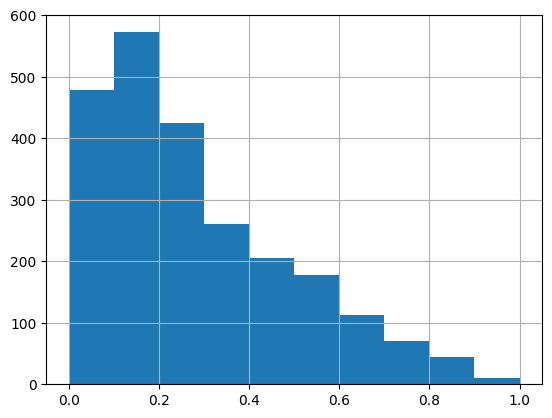

In [33]:
cilia_ab_c['Random Forest probabilities'].hist()

In [43]:
cilia_ab_c[cilia_ab_c['Random Forest probabilities']>=0.9]#.to_csv('top_ciliary_probabilties.csv')

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,GeneAB,Random Forest predictions,Random Forest probabilities,Prob_Bin,Gene_A,Gene_B,Same_Complex
131,0.280065,0.457387,0.344226,0.278140,0.105596,0.267543,0.048958,0.345802,0.602991,0.265112,...,0.893911,0.820210,0.182126,DNAH7_ARMC3,1,0.92,4,DNAH7,ARMC3,0
1017,0.209807,0.400355,0.350241,0.225984,0.098923,0.292140,0.080789,0.354788,0.592747,0.217169,...,0.883005,0.884360,0.257294,DNAH7_SPEF2,1,0.90,4,DNAH7,SPEF2,0
1181,0.186974,0.450345,0.424645,0.224743,0.109704,0.432221,0.040895,0.425352,0.588267,0.259274,...,0.876482,0.777081,0.340529,CFAP45_CFAP300,1,0.91,4,CFAP45,CFAP300,0
1344,0.325937,0.384749,0.429546,0.317125,0.165360,0.440951,0.126227,0.431846,0.594053,0.400239,...,0.879826,0.797378,0.304620,CIBAR2_DYDC2,1,0.90,4,CIBAR2,DYDC2,0
1404,0.208657,0.440549,0.380993,0.225661,0.109810,0.356503,0.055337,0.381691,0.562834,0.259723,...,0.864765,0.747805,0.104531,CFAP300_DYNLT4,1,0.96,4,CFAP300,DYNLT4,0
1411,0.198581,0.358456,0.375841,0.244173,0.112051,0.219069,0.060698,0.376790,0.384487,0.231769,...,0.824420,0.764203,0.126221,DPCD_DYNLT4,1,0.90,4,DPCD,DYNLT4,0
1423,0.256492,0.433497,0.385070,0.273415,0.143365,0.287377,0.059905,0.385902,0.549363,0.305910,...,0.864525,0.786964,0.395272,RSPH9_DYNLT4,1,0.92,4,RSPH9,DYNLT4,0
1583,0.215785,0.347286,0.374271,0.266259,0.107773,0.323266,0.037381,0.374705,0.534527,0.333650,...,0.877169,0.764525,0.552746,CFAP45_SPAG6,1,0.91,4,CFAP45,SPAG6,0
1721,0.299345,0.409764,0.324771,0.219217,0.103579,0.264314,0.097743,0.326032,0.549215,0.265855,...,0.887978,0.792104,0.211387,RSPH4A_RSPH9,1,1.00,4,RSPH4A,RSPH9,1
2230,0.136145,0.352463,0.317294,0.108980,0.112843,0.280344,0.067156,0.317544,0.554594,0.253898,...,0.921747,0.899929,0.243697,TCTN2_TMEM231,1,0.98,4,TCTN2,TMEM231,1


In [44]:
cilia_ab_c[cilia_ab_c['Random Forest probabilities']<=0.00]#.to_csv('bottom_ciliary_probabilities.csv')

,scGPT_bc_embeddings_Cosine_Similarity,scGPT_pancancer_embeddings_Cosine_Similarity,scGPT_CP_embeddings_similarities,scGPT_lung_embeddings_Cosine_Similarity,scGPT_heart_embeddings_Cosine_Similarity,scGPT_brain_embeddings_Cosine_Similarity,scGPT_kidney_embeddings_Cosine_Similarity,scGPT_human_embeddings_Cosine_Similarity,GF-6L30M_HUMANemb_Cosine_Similarity,GF-20L95M_HUMANemb_Cosine_Similarity,...,GF-12L95MCANCER_UNIPROT_HUMANemb_Cosine_Similarity,GF-12L30M_HUMANemb_Cosine_Similarity,Correlation,GeneAB,Random Forest predictions,Random Forest probabilities,Prob_Bin,Gene_A,Gene_B,Same_Complex
327,0.018519,0.160493,0.036165,0.008527,0.015626,0.009171,-0.029753,0.036869,0.352743,0.120364,...,0.803138,0.712109,0.376991,C1orf87_CFAP298,0,0.0,0,C1orf87,CFAP298,0
351,-0.020388,0.161613,0.052781,0.069227,0.071969,0.112507,0.060433,0.052947,0.330282,0.168461,...,0.871615,0.779149,0.058686,NME9_CFAP298,0,0.0,0,NME9,CFAP298,0
900,0.109368,0.207321,0.060637,0.115682,0.040896,0.010421,0.017447,0.054397,0.412702,0.228846,...,0.848155,0.812411,0.413137,C7orf57_CDHR3,0,0.0,0,C7orf57,CDHR3,0
1016,-0.000481,0.270013,0.058789,0.092928,0.104051,-0.035231,0.056334,0.059317,0.495326,0.238916,...,0.851549,0.739738,0.504541,GAS2L2_SPEF2,0,0.0,0,GAS2L2,SPEF2,0
1490,0.108524,0.129088,0.032387,0.076643,0.005990,-0.008882,-0.031929,0.032741,0.376803,0.214399,...,0.828711,0.749206,0.398197,TTC23L_RFX3,0,0.0,0,TTC23L,RFX3,0
1652,-0.002709,0.296664,0.123984,0.032127,0.022442,0.058092,-0.006794,0.124872,0.653386,0.289308,...,0.859852,0.722583,0.358654,GAS2L2_SPAG17,0,0.0,0,GAS2L2,SPAG17,0
1901,0.088052,0.301318,-0.005400,0.046020,-0.000714,0.030132,-0.045118,-0.006626,0.465439,0.178628,...,0.841710,0.677836,-0.043601,CDHR3_TEKT4,0,0.0,0,CDHR3,TEKT4,0
1954,0.024450,0.063235,0.061013,-0.034428,0.013860,0.143567,-0.019773,0.058021,0.345693,0.243767,...,0.825804,0.762758,0.126442,ENO4_TPPP3,0,0.0,0,ENO4,TPPP3,0
1974,0.062120,0.190157,0.180763,0.071984,0.025940,0.247607,-0.005092,0.178541,0.435752,0.282280,...,0.835645,0.772723,0.041837,NEK5_TPPP3,0,0.0,0,NEK5,TPPP3,0
2316,-0.002740,0.334227,0.060353,0.054462,0.071801,-0.025880,0.023754,0.062888,0.631112,0.274459,...,0.875413,0.762721,0.301034,GAS2L2_DNAH7,0,0.0,0,GAS2L2,DNAH7,0
